# Boundary Parameter Test Comparison

This notebook compares the current summed-map, no-DIG catalog to the boundary-test catalogs written by `python -m m33_pipeline.test_boundary`. It intentionally focuses only on observed Halpha luminosity and luminosity versus radius.

In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
REPO_ROOT = next((p for p in (_here, *_here.parents) if (p / 'm33_pipeline').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f'Could not locate repo root from {_here}')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
print(f'Working directory: {Path.cwd()}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

from m33_pipeline.reporting import write_latex_commands

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.linewidth': 1.3,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})
plt.rcParams['text.usetex'] = False

TEST_ROOT = Path('test_boundary')
PLOT_DIR = TEST_ROOT / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
DISTANCE_MPC = 0.84
DISTANCE_CM = DISTANCE_MPC * 1.0e6 * 3.085677581491367e18
LUMINOSITY_FACTOR = 4.0 * np.pi * DISTANCE_CM**2
BOUNDARY_VARIANTS = ['strict_small', 'loose_large']
DIG_MODES = ['no_dig', 'dig_subtracted']


Working directory: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1


In [2]:
def first_existing(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    raise FileNotFoundError('None of these paths exist: ' + ', '.join(map(str, paths)))


def add_observed_halpha_columns(df):
    out = df.copy()
    if 'L_Ha_observed' not in out.columns:
        flux_col = 'F_Halpha_sum_nodig' if 'F_Halpha_sum_nodig' in out.columns else 'F_Halpha_sum'
        out['L_Ha_observed'] = LUMINOSITY_FACTOR * pd.to_numeric(out[flux_col], errors='coerce')
    with np.errstate(divide='ignore', invalid='ignore'):
        out['log_L_Ha_observed'] = np.log10(pd.to_numeric(out['L_Ha_observed'], errors='coerce'))
    if 'radius_areaeq_pc_after_carve' in out.columns:
        out['radius_for_compare_pc'] = pd.to_numeric(out['radius_areaeq_pc_after_carve'], errors='coerce')
    else:
        out['radius_for_compare_pc'] = pd.to_numeric(out['radius_areaeq_pc'], errors='coerce')
    return out


def all_lines_snr_mask(df, snr_cut=3.0):
    snr_cols = [
        'SNR_Halpha_sum',
        'SNR_Hbeta_sum',
        'SNR_[OIII]5007_sum',
        'SNR_[SII]6716_sum',
        'SNR_[NII]6583_sum',
    ]
    mask = np.ones(len(df), dtype=bool)
    for col in snr_cols:
        if col not in df.columns:
            return np.zeros(len(df), dtype=bool)
        mask &= pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float) > snr_cut
    return mask


def analysis_sample(df):
    out = df.copy()
    if 'primary' in out.columns:
        out = out.loc[out['primary'].fillna(True)].copy()
    if 'BPT_class_sum_dered' not in out.columns:
        return out.iloc[0:0].copy()
    mask = (out['BPT_class_sum_dered'] == 'Star-forming') & all_lines_snr_mask(out)
    return out.loc[mask].copy().reset_index(drop=True)


def load_current_catalog(dig_mode):
    base = Path('CATALOGS') / 'flux_catalogs' / 'summed_map' / dig_mode
    path = first_existing([base / 'total_flux_catalog_combined.csv', base / 'total_flux_catalog.csv'])
    return add_observed_halpha_columns(pd.read_csv(path)), path


def load_boundary_catalog(variant, dig_mode):
    candidates = [
        TEST_ROOT / 'flux_catalogs' / dig_mode / variant / 'total_flux_catalog.csv',
        TEST_ROOT / 'flux_catalogs' / variant / 'total_flux_catalog.csv',  # compatibility with older no-DIG runs
    ]
    path = next((candidate for candidate in candidates if candidate.exists()), None)
    if path is None:
        print(f'Missing boundary-test catalog for {variant}/{dig_mode}; run the boundary test pipeline before plotting it.')
        return None, None
    return add_observed_halpha_columns(pd.read_csv(path)), path


def load_catalogs_for_dig_mode(dig_mode):
    catalogs = {}
    sources = {}
    current, current_path = load_current_catalog(dig_mode)
    catalogs['current'] = current
    sources['current'] = current_path
    for variant in BOUNDARY_VARIANTS:
        df, path = load_boundary_catalog(variant, dig_mode)
        if df is not None:
            catalogs[variant] = df
            sources[variant] = path
    return catalogs, sources

catalogs_by_dig_mode = {}
sources_by_dig_mode = {}
for dig_mode in DIG_MODES:
    catalogs, sources = load_catalogs_for_dig_mode(dig_mode)
    catalogs_by_dig_mode[dig_mode] = catalogs
    sources_by_dig_mode[dig_mode] = sources
    for name, df in catalogs.items():
        sample = analysis_sample(df)
        n_lum = np.isfinite(sample['log_L_Ha_observed']).sum()
        n_rad = (np.isfinite(sample['log_L_Ha_observed']) & np.isfinite(sample['radius_for_compare_pc']) & (sample['radius_for_compare_pc'] > 0)).sum()
        print(f'{dig_mode}/{name}: rows={len(df)}, SF SNR>3={len(sample)}, luminosities={n_lum}, L-R points={n_rad}')


no_dig/current: rows=6423, SF SNR>3=4975, luminosities=4975, L-R points=4975
no_dig/strict_small: rows=6423, SF SNR>3=0, luminosities=0, L-R points=0
no_dig/loose_large: rows=6423, SF SNR>3=0, luminosities=0, L-R points=0
dig_subtracted/current: rows=6423, SF SNR>3=4578, luminosities=4578, L-R points=4578
dig_subtracted/strict_small: rows=6423, SF SNR>3=0, luminosities=0, L-R points=0
dig_subtracted/loose_large: rows=6423, SF SNR>3=0, luminosities=0, L-R points=0


In [3]:
def summarize_boundary_catalog(name, dig_mode, df):
    sample = analysis_sample(df)
    radius = pd.to_numeric(sample['radius_for_compare_pc'], errors='coerce').to_numpy(dtype=float)
    lum = pd.to_numeric(sample['L_Ha_observed'], errors='coerce').to_numpy(dtype=float)
    log_r = np.full_like(radius, np.nan, dtype=float)
    log_l = np.full_like(lum, np.nan, dtype=float)
    good = np.isfinite(radius) & np.isfinite(lum) & (radius > 0) & (lum > 0)
    log_r[good] = np.log10(radius[good])
    log_l[good] = np.log10(lum[good])
    row = {
        'catalog': name,
        'dig_mode': dig_mode,
        'n': int(good.sum()),
        'mean_log_radius': float(np.nanmean(log_r[good])) if good.any() else np.nan,
        'spread_log_radius': float(np.nanstd(log_r[good], ddof=1)) if good.sum() > 1 else np.nan,
        'mean_log_luminosity': float(np.nanmean(log_l[good])) if good.any() else np.nan,
        'spread_log_luminosity': float(np.nanstd(log_l[good], ddof=1)) if good.sum() > 1 else np.nan,
        'slope_log_luminosity_log_radius': np.nan,
        'slope_err_log_luminosity_log_radius': np.nan,
        'intercept_log_luminosity_log_radius': np.nan,
        'intercept_err_log_luminosity_log_radius': np.nan,
    }
    if good.sum() >= 3:
        fit = linregress(log_r[good], log_l[good])
        row.update({
            'slope_log_luminosity_log_radius': float(fit.slope),
            'slope_err_log_luminosity_log_radius': float(fit.stderr),
            'intercept_log_luminosity_log_radius': float(fit.intercept),
            'intercept_err_log_luminosity_log_radius': float(fit.intercept_stderr),
        })
    return row


summary_rows = []
for dig_mode, catalogs in catalogs_by_dig_mode.items():
    for name, df in catalogs.items():
        summary_rows.append(summarize_boundary_catalog(name, dig_mode, df))

boundary_summary = pd.DataFrame(summary_rows)
boundary_summary_path = TEST_ROOT / 'boundary_test_sf_snrthree_summary.csv'
boundary_summary.to_csv(boundary_summary_path, index=False)
print(f'Wrote boundary-test summary CSV: {boundary_summary_path}')

tex_values = {}
tex_formats = {}
for row in summary_rows:
    prefix = f"boundary{row['dig_mode'].title().replace('_', '')}{row['catalog'].title().replace('_', '')}"
    tex_values[f'{prefix}NRegions'] = row['n']
    for key in [
        'mean_log_radius',
        'spread_log_radius',
        'mean_log_luminosity',
        'spread_log_luminosity',
        'slope_log_luminosity_log_radius',
        'slope_err_log_luminosity_log_radius',
        'intercept_log_luminosity_log_radius',
        'intercept_err_log_luminosity_log_radius',
    ]:
        command_key = ''.join(part.title() for part in key.split('_'))
        tex_values[f'{prefix}{command_key}'] = row[key]
        tex_formats[f'{prefix}{command_key}'] = '.3f'

boundary_numbers_path = TEST_ROOT / 'boundary_test_numbers.tex'
write_latex_commands(boundary_numbers_path, tex_values, tex_formats)
print(f'Wrote boundary-test TeX commands: {boundary_numbers_path}')
display(boundary_summary)


Wrote boundary-test summary CSV: test_boundary/boundary_test_sf_snrthree_summary.csv
Wrote boundary-test TeX commands: test_boundary/boundary_test_numbers.tex


,catalog,dig_mode,n,mean_log_radius,spread_log_radius,mean_log_luminosity,spread_log_luminosity,slope_log_luminosity_log_radius,slope_err_log_luminosity_log_radius,intercept_log_luminosity_log_radius,intercept_err_log_luminosity_log_radius
0,current,no_dig,4975,1.086201,0.153909,35.868865,0.526788,2.185387,0.037355,33.495096,0.040980
1,strict_small,no_dig,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,loose_large,no_dig,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,current,dig_subtracted,4578,1.086116,0.155257,35.867501,0.532518,2.172366,0.039237,33.508060,0.043049
4,strict_small,dig_subtracted,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,loose_large,dig_subtracted,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


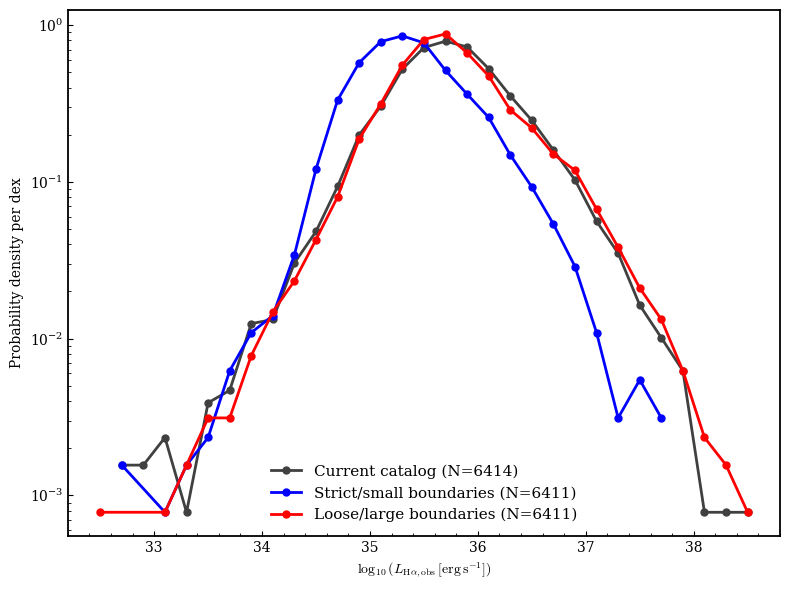

In [10]:
colors = {
    'current': '0.25',
    'strict_small': 'blue',
    'loose_large': 'red',
}
labels = {
    'current': 'Current catalog',
    'strict_small': 'Strict/small boundaries',
    'loose_large': 'Loose/large boundaries',
}


def luminosity_pdf_points(log_luminosity, bins):
    log_luminosity = np.asarray(log_luminosity, dtype=float)
    log_luminosity = log_luminosity[np.isfinite(log_luminosity)]
    counts, edges = np.histogram(log_luminosity, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    if counts.sum() == 0:
        return centers, np.full_like(centers, np.nan, dtype=float), counts
    pdf = counts / (counts.sum() * widths)
    return centers[counts > 0], pdf[counts > 0], counts[counts > 0]


all_log_l = np.concatenate([
    pd.to_numeric(df['log_L_Ha_observed'], errors='coerce').to_numpy(dtype=float)
    for df in catalogs.values()
])
all_log_l = all_log_l[np.isfinite(all_log_l)]
bins = np.arange(np.floor(all_log_l.min() * 5) / 5, np.ceil(all_log_l.max() * 5) / 5 + 0.2, 0.2)

fig, ax = plt.subplots(figsize=(8, 6))
for name, df in catalogs_by_dig_mode['dig_subtracted'].items():
    x, y, counts = luminosity_pdf_points(df['log_L_Ha_observed'], bins)
    ax.plot(x, y, marker='o', lw=2.0, ms=5, color=colors.get(name), label=f'{labels.get(name, name)} (N={counts.sum()})')
ax.set_xlabel(r'$\log_{10}(L_{\rm H\alpha,obs}\,[{\rm erg\,s}^{-1}])$')
ax.set_ylabel('Probability density per dex')
ax.set_yscale('log')
ax.minorticks_on()
ax.legend(frameon=False, fontsize=11)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'boundary_test_halpha_luminosity_function.png', dpi=300, bbox_inches='tight')
plt.show()


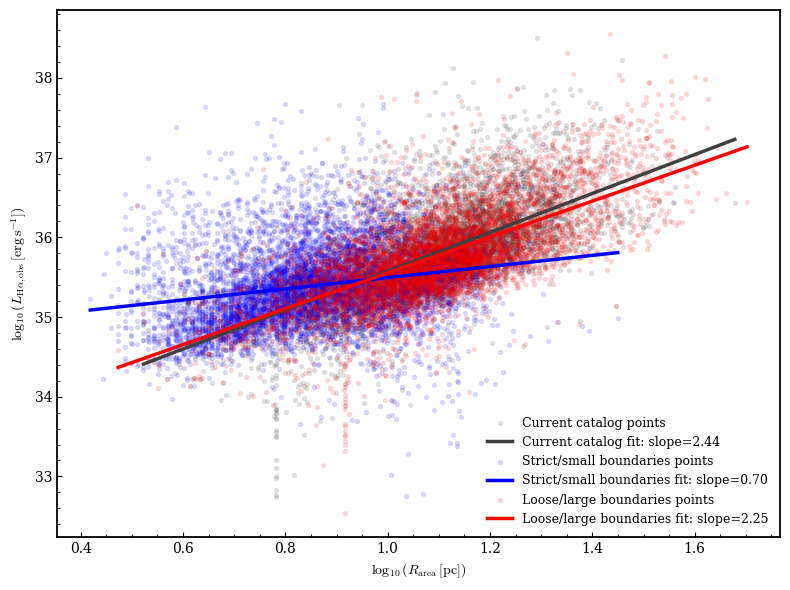

,catalog,n,slope_logL_logR,intercept,slope_stderr,intercept_stderr
0,current,6414,2.439668,33.134541,0.033629,0.036528
1,strict_small,6411,0.699159,34.794902,0.040138,0.034688
2,loose_large,6411,2.251453,33.302506,0.030497,0.033621


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
fit_rows = []
for name, df in catalogs_by_dig_mode['dig_subtracted'].items():
    radius = pd.to_numeric(df['radius_for_compare_pc'], errors='coerce').to_numpy(dtype=float)
    lum = pd.to_numeric(df['L_Ha_observed'], errors='coerce').to_numpy(dtype=float)
    mask = np.isfinite(radius) & np.isfinite(lum) & (radius > 0) & (lum > 0)
    log_r = np.log10(radius[mask])
    log_l = np.log10(lum[mask])
    ax.scatter(log_r, log_l, s=8, alpha=0.12, color=colors.get(name), label=f'{labels.get(name, name)} points')
    if len(log_r) >= 2:
        fit = linregress(log_r, log_l)
        xgrid = np.linspace(np.nanmin(log_r), np.nanmax(log_r), 200)
        ax.plot(xgrid, fit.slope * xgrid + fit.intercept, color=colors.get(name), lw=2.5, label=f'{labels.get(name, name)} fit: slope={fit.slope:.2f}')
        fit_rows.append({
            'catalog': name,
            'n': len(log_r),
            'slope_logL_logR': fit.slope,
            'intercept': fit.intercept,
            'slope_stderr': fit.stderr,
            'intercept_stderr': fit.intercept_stderr,
        })
ax.set_xlabel(r'$\log_{10}(R_{\rm area}\,[{\rm pc}])$')
ax.set_ylabel(r'$\log_{10}(L_{\rm H\alpha,obs}\,[{\rm erg\,s}^{-1}])$')
ax.minorticks_on()
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'boundary_test_luminosity_radius.png', dpi=300, bbox_inches='tight')
plt.show()

fit_summary = pd.DataFrame(fit_rows)
display(fit_summary)
fit_summary.to_csv(TEST_ROOT / 'boundary_test_luminosity_radius_fit_summary.csv', index=False)


In [12]:
for name, df in catalogs_by_dig_mode['dig_subtracted'].items():
    sample = analysis_sample(df)
    radius = pd.to_numeric(sample['radius_for_compare_pc'], errors='coerce').to_numpy(dtype=float)
    lum = pd.to_numeric(sample['L_Ha_observed'], errors='coerce').to_numpy(dtype=float)
    mask = np.isfinite(radius) & np.isfinite(lum) & (radius > 0) & (lum > 0)
    log_r = np.log10(radius[mask])
    log_l = np.log10(lum[mask])
    print(f'{name}: {len(log_r)} points for L-R fit')

current: 4578 points for L-R fit
strict_small: 0 points for L-R fit
loose_large: 0 points for L-R fit


In [27]:
snr_cut = 3.0
#only show regions that have snr>3 in all lines
current_snr = catalogs_by_dig_mode['dig_subtracted']['current']
r_current = catalogs_by_dig_mode['dig_subtracted']['current']['radius_areaeq_pc']
print(np.mean(r_current))

r_loose = catalogs_by_dig_mode['dig_subtracted']['loose_large']['radius_areaeq_pc']
print(np.mean(r_loose))

r_small = catalogs_by_dig_mode['dig_subtracted']['strict_small']['radius_areaeq_pc']
print(np.mean(r_small))

12.678577745431515
13.314754377866818
7.570812920658896
